# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

# Loading and Determining Population

In [6]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['AggregatedPop1027', 'meuse', 'RegularPop1000', 'cluster', 'random', 'swiss', 'grid'])
dict_keys(['AggregatedPop1027', 'meuse', 'RegularPop1000', 'cluster', 'random', 'swiss', 'grid'])
dict_keys(['unequal', 'equal'])


In [7]:
n = 4
coords = coords_dict['swiss']
probs = probs_dict['swiss']['unequal']
N = len(probs)
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

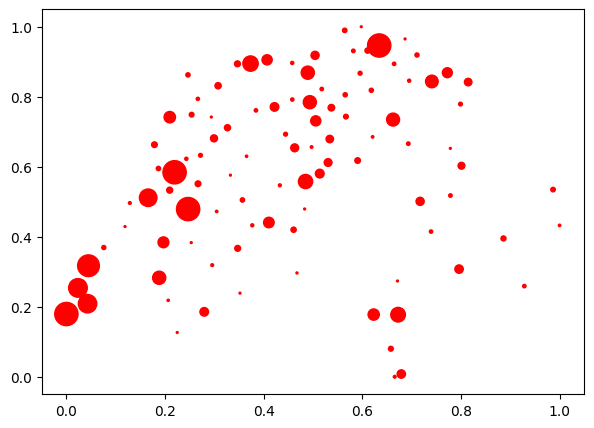

In [8]:
import matplotlib.pyplot as plt
x = coords[:, 0]
y = coords[:, 1]

plt.figure(figsize=(7,5))
plt.scatter(x, y, s=1000*modified_probs, color = 'red')
plt.show()

# Building Initial Designs

In [9]:
orders = [
    # "lexico-yx",
    # "lexico-xy",
    # "random",
    # "angle_0",
    # "distance_0",
    # "projection",
    # "center",
    "spiral",
    # "max",
    # "snake",
    # "hilbert",
]

In [10]:
initial_designs = []
combines = list(itertools.product(orders, orders))
num_trials = 2
for units_order, zones_order in tqdm(combines, desc="Generating initial designs", total=len(combines), unit="orders"):
    best = None
    best_score = np.inf
    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,
            n_zones=(2, 2),
            zone_builder='sweep',
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))

    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,
            n_zones=(1, 1),
            zone_builder='sweep',
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))


Generating initial designs:   0%|          | 0/1 [00:00<?, ?orders/s]

Generating initial designs: 100%|██████████| 1/1 [00:08<00:00,  8.00s/orders]


In [11]:
for design in initial_designs:
    print(design.kmeans.all_samples.shape, design.kmeans.expected_moran_score())

(111, 4) -0.1690369354473907
(111, 4) -0.1690369354473907


# Run Astar

In [12]:
moran_criteria = gs.criteria.MoranCriteria()

In [13]:
astar = gs.search.AStar(
    initial_designs,
    moran_criteria
)

best initial criteria value -0.1690369354473907


In [14]:
import time

t0 = time.perf_counter()
astar.run(
    max_iterations=100,
    num_new_nodes=10,
    max_open_set_size=1000,
    n_clusters_to_change_order_zone=0,
    n_changes_in_order_of_zones=0,
    n_clusters_to_change_order_units=1,
    n_zones_to_change_order_units=1,
    n_changes_in_order_of_units=1,
    n_jobs=-1,
)
elapsed_astar = time.perf_counter() - t0
print(f"A* time: {elapsed_astar:.2f} seconds")


parent node: -0.1690369354473907
iteration: 0, child node: -0.1697198617632421

iteration: 0, New best criteria value: -0.1697198617632421

iteration: 0, child node: -0.1690214581533907
iteration: 0, child node: -0.16894126360060263
iteration: 0, child node: -0.1690388865810498
iteration: 0, child node: -0.1690334572786286
iteration: 0, child node: -0.16902993288591908
iteration: 0, child node: -0.1697892582441467

iteration: 0, New best criteria value: -0.1697892582441467


parent node: -0.1697892582441467


/config/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


iteration: 1, child node: -0.17046272953867414

iteration: 1, New best criteria value: -0.17046272953867414

iteration: 1, child node: -0.16913566125318247
iteration: 1, child node: -0.16947188846422892
iteration: 1, child node: -0.16974542477639123
iteration: 1, child node: -0.16280869354800726
iteration: 1, child node: -0.1702488012400037
iteration: 1, child node: -0.1697892582441467
iteration: 1, child node: -0.16916175911205583

parent node: -0.17046272953867414
iteration: 2, child node: -0.1699139999314106
iteration: 2, child node: -0.1704724947734304

iteration: 2, New best criteria value: -0.1704724947734304

iteration: 2, child node: -0.17034400262668672
iteration: 2, child node: -0.16892589925998286
iteration: 2, child node: -0.17033275244588256
iteration: 2, child node: -0.17020892384890862
iteration: 2, child node: -0.170179913137891
iteration: 2, child node: -0.17077313608249578

iteration: 2, New best criteria value: -0.17077313608249578

iteration: 2, child node: -0.17021

In [15]:
astar.best_criteria_value

-0.18268010739201593

In [16]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,0.187445,0.317742
moran,-0.182680,0.084906
local_balance,1.188679,1.552123
voronoi,0.096511,0.071177


In [17]:
np.mean(np.abs(astar.best_design.kmeans.fips - modified_probs))

np.float64(3.657484514904552e-13)

In [18]:
astar.best_design.kmeans.all_samples_probs.sum()

np.float64(0.9999999999989999)

# Run Bees

In [28]:
bee = gs.search.Bees(
    initial_designs,
    gs.criteria.MoranCriteria(),
    colony_size=20,
    limit=200,
)

Evaluating initial designs...
ABC initialized - Best initial criteria value: -0.1690369354473907


In [30]:
bee.run(
    max_iterations = 1_000,

    n_clusters_to_change_order_zone = 0,
    n_changes_in_order_of_zones = 0,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1,

    max_time_seconds=elapsed_astar
)


Starting ABC with 20 food sources
Colony size: 20, Limit: 200

Iteration 1/1000
  Best: -0.175029, Avg: -0.169052

Iteration 2/1000
  Best: -0.175029, Avg: -0.169109

Iteration 3/1000
  Best: -0.175029, Avg: -0.169174

Iteration 4/1000
  Best: -0.175029, Avg: -0.169268

Iteration 5/1000
  Best: -0.175029, Avg: -0.169421

Iteration 6/1000
  Best: -0.175029, Avg: -0.169664

Iteration 7/1000
  Best: -0.175029, Avg: -0.169833

Iteration 8/1000
  Best: -0.175029, Avg: -0.169835

Iteration 9/1000
  Best: -0.175029, Avg: -0.169908

Iteration 10/1000
  Best: -0.175029, Avg: -0.170018

Iteration 11/1000
  Best: -0.175029, Avg: -0.170147

Iteration 12/1000
  Best: -0.175029, Avg: -0.170221

Iteration 13/1000
  Best: -0.175029, Avg: -0.170289

Iteration 14/1000
  Best: -0.175029, Avg: -0.170454

Iteration 15/1000
  Best: -0.175029, Avg: -0.170498

Iteration 16/1000
  Best: -0.175029, Avg: -0.170568

Iteration 17/1000
  Best: -0.175029, Avg: -0.170846

Iteration 18/1000
  Best: -0.175029, Avg: -0

28